## Step 1: Imports

Loads the libraries needed for this notebook — `pandas`/`numpy` for data handling, `train_test_split` for the 80/20 evaluation split, `LinearRegression` as the model, and evaluation metrics (`mean_absolute_error`, `mean_squared_error`, `r2_score`) to score it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

## Step 2: Load the Data

Loads the raw `train.csv` and `test.csv` files. `id_column` and `price_column` are set here as placeholders so the rest of the notebook can reference them generically instead of hardcoding `"Id"` and `"SalePrice"` everywhere.

In [2]:

df_train = pd.read_csv("House_Prices_DataSet/train.csv")
df_test = pd.read_csv("House_Prices_DataSet/test.csv")

id_column = "Id"
price_column = "SalePrice"


print(f"train.csv: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"test.csv: {df_test.shape[0]} rows, {df_test.shape[1]} columns")


train.csv: 1460 rows, 81 columns
test.csv: 1459 rows, 80 columns


## Step 3: Separate Target and Combine Datasets for Safety

Pulls `SalePrice` out of the training data into `y`, then tags each row with its origin (`"train"` or `"test"`) before stacking `train` and `test` into one combined DataFrame. Combining them ensures the encoding step further down produces identical columns for both sets — otherwise a category present in one file but not the other would cause mismatched columns later.

In [3]:
y = df_train[price_column]
X_train_raw = df_train.drop(columns=[price_column])
X_test_raw = df_test.copy()

X_train_raw["__source__"] = "train"
X_test_raw["__source__"] = "test"


combined = pd.concat([X_train_raw, X_test_raw], axis=0, ignore_index=True)

print(f"Combined shape before encoding: {combined.shape}")

Combined shape before encoding: (2919, 81)


## Step 4: Fill Missing Data (Imputation)

Patches empty cells so the model doesn't crash on missing values:

* **Numeric columns**: filled with the column's median.
* **Categorical (text) columns**: filled with `"None"` — many of these NaNs genuinely mean "feature absent" (e.g. no basement, no garage) rather than missing data.

In [4]:

numeric_cols = combined.select_dtypes(include=[np.number]).columns
combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

categorical_cols = combined.select_dtypes(include=["object"]).columns
combined[categorical_cols] = combined[categorical_cols].fillna("None")

## Step 5: Convert Text to Numbers (One-Hot Encoding)

Converts every categorical column into binary (0/1) columns using `pd.get_dummies()`, so the model can work with the data numerically. `drop_first=True` drops one category per column to avoid the dummy-variable trap (multicollinearity).

In [5]:

source_flag = combined["__source__"]
ids_all = combined[id_column]

features_to_encode = combined.drop(columns=[id_column, "__source__"])

encoded = pd.get_dummies(features_to_encode, drop_first=True)

print(f"Encoded shape: {encoded.shape}")

Encoded shape: (2919, 267)


## Step 6: Separate Data Back Into Train/Test

Splits the encoded `encoded` DataFrame back into `X_full_train` and `X_full_test` using the `__source__` tag from Step 2, so each set is aligned with the same one-hot columns.

In [6]:

X_full_train = encoded[source_flag.values == "train"].reset_index(drop=True)
X_full_test = encoded[source_flag.values == "test"].reset_index(drop=True)

id_train_full = ids_all[source_flag.values == "train"].reset_index(drop=True)
id_test_full = ids_all[source_flag.values == "test"].reset_index(drop=True)

print(f"Encoded training features: {X_full_train.shape}")
print(f"Encoded test features (for final submission): {X_full_test.shape}")

Encoded training features: (1460, 267)
Encoded test features (for final submission): (1459, 267)


## Step 7: 80/20 Split for Evaluation

Splits `X_full_train` (the only set with real prices) into an 80% training portion and a 20% validation portion, so model performance can be checked locally before making predictions on the unlabeled `test.csv`.

In [7]:

X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_full_train, y, id_train_full,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Validation rows: {X_val.shape[0]}")

Training rows: 1168
Validation rows: 292


## Step 8: Train the Model (RandomForestRegressor)


In [8]:

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

## Step 9: Evaluate on the Validation Split

Uses the trained model to predict prices for the held-out 20% validation set (`X_val`), then scores those predictions against the real prices (`y_val`) using three metrics:

* **MAE** — average absolute dollar error.
* **RMSE** — root mean squared error, penalizes large misses more heavily.
* **R²** — proportion of price variance the model explains (closer to 1.0 is better).

In [9]:

y_val_pred = model.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $17,569.57
RMSE: $28,983.66
R²:   0.8905


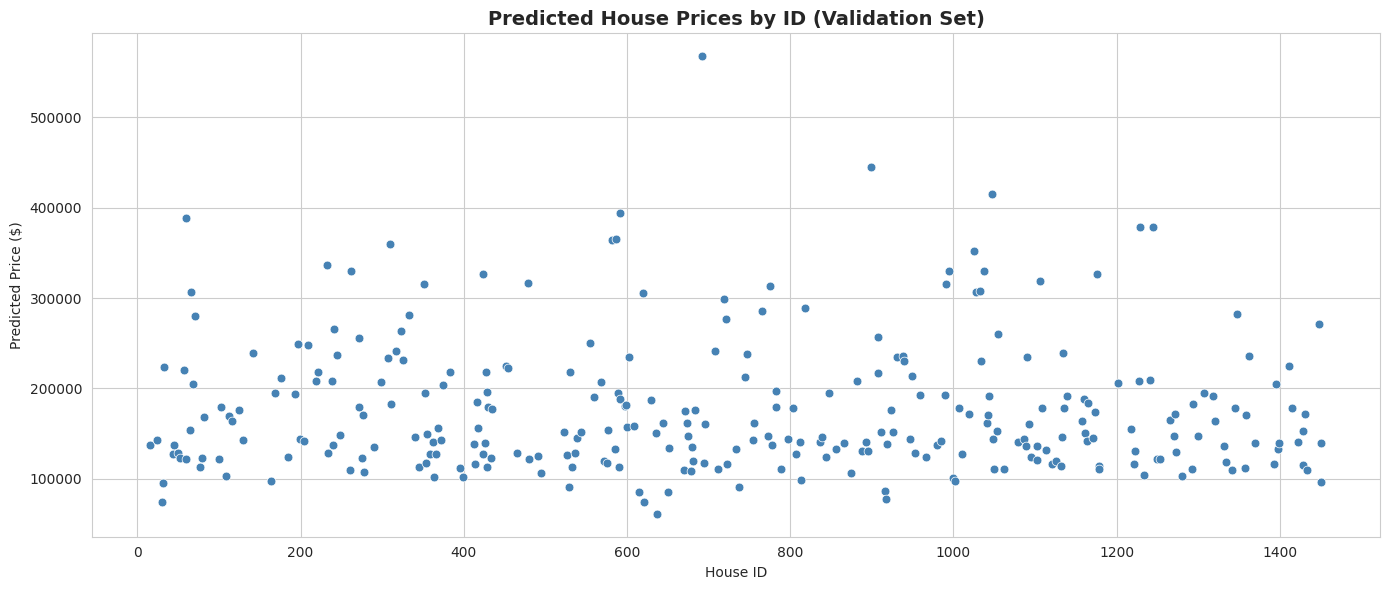

In [10]:

results_df = pd.DataFrame({
    id_column: id_val,
    "Predicted_Price": y_val_pred
}).sort_values(by=id_column)

plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=results_df,
    x=id_column,
    y="Predicted_Price",
    color="steelblue",
    s=40
)

plt.title("Predicted House Prices by ID (Validation Set)", fontsize=14, fontweight="bold")
plt.xlabel("House ID")
plt.ylabel("Predicted Price ($)")
plt.tight_layout()
plt.show()

## Step 10: Create the Final Submission File

Runs the trained model on `X_full_test` — the real, unlabeled `test.csv` set — to generate final price predictions. Pairs each prediction with its `Id` and saves the result to `submission.csv`.

In [11]:

test_predictions = model.predict(X_full_test)

submission_df = pd.DataFrame({
    id_column: id_test_full,
    price_column: test_predictions
})

submission_df.to_csv("submission.csv", index=False)
submission_df.head()

,Id,SalePrice
0,1461,127331.250
1,1462,153463.500
2,1463,178949.595
3,1464,187023.125
4,1465,204487.395


In [12]:
submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


## Step 11: Download the Submission File

Generates a clickable link directly in the notebook output so `submission.csv` can be downloaded without leaving the notebook or digging through the Jupyter file browser.

In [13]:
from IPython.display import FileLink
FileLink('submission.csv')

/home/Student/submission.csv